In [3]:
install.packages("DirichletReg")
install.packages("jsonlite")
install.packages("readr")
install.packages("ggplot2")
install.packages("gridExtra")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
library(DirichletReg)
library(jsonlite)
library(readr)
library(ggplot2)
library(gridExtra)

Loading required package: Formula



In [127]:
CONFIG <- list(
  training_data_file = "data_preparation_result.csv",
  model_output_file = "dirichlet_model.rds",
  n_bins = 5,
  campaign_duration = 60,
  target_dana = 1000000,
  platform_fee = 0.05,
  bin_values = c(3136, 19406, 45707, 95382, 568843)
)

In [128]:
load_data <- function(config) {
  cat("Loading training data from:", config$training_data_file, "\n")
  if (grepl("\\.json$", config$training_data_file)) {
    training_data <- fromJSON(config$training_data_file)
    if (is.list(training_data) && !is.data.frame(training_data)) {
      training_data <- as.data.frame(training_data)
    }
  } else {
    training_data <- read_csv(config$training_data_file, show_col_types = FALSE)

    cat("DIM:", paste(dim(training_data), collapse=" x "), "\n")
    cat("NAMES RAW:\n"); dput(names(training_data))
    print(head(training_data, 2))
  }

  cat("Loaded", nrow(training_data), "campaigns\n\n")

  if (is.null(config$bin_values)) {
    cat("Loading bin values from:", config$bin_values_file, "\n")

    if (grepl("\\.json$", config$bin_values_file)) {
      bin_data <- fromJSON(config$bin_values_file)
      if (is.list(bin_data) && "value" %in% names(bin_data)) {
        bin_values <- bin_data$value
      } else if (is.data.frame(bin_data) && "value" %in% colnames(bin_data)) {
        bin_values <- bin_data$value
      } else if (is.numeric(bin_data)) {
        bin_values <- bin_data
      } else {
        bin_values <- as.numeric(unlist(bin_data))
      }
    } else {
      bin_data <- read_csv(config$bin_values_file, show_col_types = FALSE)
      bin_values <- bin_data$value
    }

    cat("Loaded", length(bin_values), "bin values\n\n")
  } else {
    bin_values <- config$bin_values
    cat("Using provided bin values:", bin_values, "\n\n")
  }

  return(list(
    training_data = training_data,
    bin_values = bin_values
  ))
}

In [129]:
prepare_dirichlet_data <- function(training_data) {

  training_data <- as.data.frame(training_data)

  # 🔥 NORMALISASI NAMA KOLOM
  names(training_data) <- trimws(names(training_data))
  names(training_data) <- tolower(names(training_data))

  # 🔥 STRIP PREFIX (ambil bagian setelah titik terakhir)
  names(training_data) <- sub(".*\\.", "", names(training_data))

  cat("Normalized column names:\n")
  print(names(training_data))

  # auto-detect p1, p2, ...
  prob_cols <- grep("^p[0-9]+$", names(training_data), value = TRUE)

  if (length(prob_cols) == 0) {
    stop(
      "No probability columns found after normalization.\nAvailable columns: ",
      paste(names(training_data), collapse = ", ")
    )
  }

  # urutkan p1, p2, ...
  prob_cols <- prob_cols[order(as.numeric(sub("^p", "", prob_cols)))]

  cat("Detected probability columns:", paste(prob_cols, collapse = ", "), "\n")

  # ambil probability matrix
  prob_matrix <- as.matrix(training_data[, prob_cols, drop = FALSE])
  prob_matrix <- prob_matrix / rowSums(prob_matrix)

  Y <- DirichletReg::DR_data(prob_matrix)

  predictors <- training_data[, c("n", "campaign_duration", "current_donation"), drop = FALSE]
  attr(predictors, "Y") <- Y

  predictors
}

In [130]:
train_model <- function(dirichlet_data, output_file) {

  # ambil Y
  Y <- attr(dirichlet_data, "Y")

  # scaling params (LOWERCASE)
  scales <- list(
    n = list(mean = mean(dirichlet_data$n), sd = sd(dirichlet_data$n)),
    campaign_duration = list(
      mean = mean(dirichlet_data$campaign_duration),
      sd = sd(dirichlet_data$campaign_duration)
    ),
    current_donation = list(
      mean = mean(dirichlet_data$current_donation),
      sd = sd(dirichlet_data$current_donation)
    )
  )

  # scaling (LOWERCASE)
  dirichlet_data$n <- scale(dirichlet_data$n)
  dirichlet_data$campaign_duration <- scale(dirichlet_data$campaign_duration)
  dirichlet_data$current_donation <- scale(dirichlet_data$current_donation)

  # fit model (LOWERCASE di formula)
  model <- DirichReg(
    Y ~ n + campaign_duration + current_donation,
    data = dirichlet_data,
    model = "alternative"
  )

  # simpan metadata
  model$scales <- scales
  model$train_domain <- list(
    n = range(dirichlet_data$n),
    campaign_duration = range(dirichlet_data$campaign_duration),
    current_donation = range(dirichlet_data$current_donation)
  )

  saveRDS(model, output_file)
  model
}

In [138]:
calculate_ev <- function(model, N_values, bin_values, config) {

  results <- data.frame()

  for (scenario in names(N_values)) {

    # scale new data (pakai parameter training)
    new_data <- data.frame(
      n = (N_values[[scenario]] - model$scales$n$mean) / model$scales$n$sd,
      campaign_duration =
        (config$campaign_duration - model$scales$campaign_duration$mean) /
        model$scales$campaign_duration$sd,
      current_donation =
        (config$target_dana - model$scales$current_donation$mean) /
        model$scales$current_donation$sd
    )

    # CLAMP KE DOMAIN TRAINING (SEMUA LOWERCASE)
    new_data$n <- pmin(
      pmax(new_data$n, model$train_domain$n[1]),
      model$train_domain$n[2]
    )

    new_data$campaign_duration <- pmin(
      pmax(new_data$campaign_duration, model$train_domain$campaign_duration[1]),
      model$train_domain$campaign_duration[2]
    )

    new_data$current_donation <- pmin(
      pmax(new_data$current_donation, model$train_domain$current_donation[1]),
      model$train_domain$current_donation[2]
    )

    probs <- as.numeric(predict(model, newdata = new_data)[1, ])

    # numerical safety
    probs[!is.finite(probs)] <- 1e-8
    probs <- pmax(probs, 1e-8)
    probs <- probs / sum(probs)

    cat("\n----------------------------------------\n")
    cat("Predicted probabilities for scenario:", toupper(scenario), "\n")
    cat("N =", N_values[[scenario]], "\n")

    for (i in seq_along(probs)) {
      cat(sprintf(
        "  p%d = %.4f (%.2f%%)\n",
        i, probs[i], probs[i] * 100
      ))
    }
    cat("----------------------------------------\n")


    expected_per_donor <- sum(probs * bin_values)
    ev_before_fee <- N_values[[scenario]] * expected_per_donor
    ev_after_fee <- ev_before_fee * (1 - config$platform_fee)

    results <- rbind(results, data.frame(
      scenario = scenario,
      N = N_values[[scenario]],
      expected_per_donor = expected_per_donor,
      ev_before_fee = ev_before_fee,
      ev_after_fee = ev_after_fee,
      p1 = probs[1], p2 = probs[2], p3 = probs[3], p4 = probs[4], p5 = probs[5]
    ))
  }

  results
}


In [185]:
print_summary_table <- function(results) {

  # pilih & urutkan kolom
  tbl <- results[, c(
    "N",
    paste0("p", 1:5),
    "ev_before_fee",
    "ev_after_fee"
  )]

  # formatting rupiah
  tbl$ev_before_fee <- format(
    round(tbl$ev_before_fee),
    big.mark = ",",
    scientific = FALSE
  )

  tbl$ev_after_fee <- format(
    round(tbl$ev_after_fee),
    big.mark = ",",
    scientific = FALSE
  )

  # rounding probabilitas
  for (i in 1:5) {
    tbl[[paste0("p", i)]] <- round(tbl[[paste0("p", i)]], 4)
  }

  cat("\nSUMMARY TABLE (Expected Value per Scenario)\n")
  print(tbl, row.names = FALSE)
}

In [186]:
main <- function(config) {

  training_data <- load_data(config)
  dirichlet_data <- prepare_dirichlet_data(training_data)

  model <- train_model(dirichlet_data, config$model_output_file)

  N_values <- list(min = 69, avg = 1020, max = 7020)

  results <- calculate_ev(model, N_values, config$bin_values, config)
  print_summary(results)
  print_summary_table(results)

  return(list(
    model = model,
    results = results
  ))
}

out <- main(CONFIG)

model <- out$model
results <- out$results

Loading training data from: data_preparation_result.csv 
DIM: 30 x 10 
NAMES RAW:
c("campaign", "N", "campaign_duration", "current_donation", "progress", 
"p1", "p2", "p3", "p4", "p5")
# A tibble: 2 × 10
  campaign      N campaign_duration current_donation progress    p1    p2     p3
  <chr>     <dbl>             <dbl>            <dbl>    <dbl> <dbl> <dbl>  <dbl>
1 donors_a…    94               458          1619000  0.00132 0.777 0.128 0.0532
2 donors_b…  3974               101         29267000  0.0399  0.982 0.012 0.0064
# ℹ 2 more variables: p4 <dbl>, p5 <dbl>
Loaded 30 campaigns

Using provided bin values: 3136 19406 45707 95382 568843 

Normalized column names:
 [1] "campaign"          "n"                 "campaign_duration"
 [4] "current_donation"  "progress"          "p1"               
 [7] "p2"                "p3"                "p4"               
[10] "p5"                "bin_values"       
Detected probability columns: p1, p2, p3, p4, p5 


Warning message in DirichletReg::DR_data(prob_matrix):
“some entries are 0 or 1 => transformation forced”



----------------------------------------
Predicted probabilities for scenario: MIN 
N = 69 
  p1 = 0.6689 (66.89%)
  p2 = 0.1402 (14.02%)
  p3 = 0.0906 (9.06%)
  p4 = 0.0600 (6.00%)
  p5 = 0.0402 (4.02%)
----------------------------------------

----------------------------------------
Predicted probabilities for scenario: AVG 
N = 1020 
  p1 = 0.7219 (72.19%)
  p2 = 0.1196 (11.96%)
  p3 = 0.0737 (7.37%)
  p4 = 0.0498 (4.98%)
  p5 = 0.0350 (3.50%)
----------------------------------------

----------------------------------------
Predicted probabilities for scenario: MAX 
N = 7020 
  p1 = 0.9256 (92.56%)
  p2 = 0.0349 (3.49%)
  p3 = 0.0158 (1.58%)
  p4 = 0.0121 (1.21%)
  p5 = 0.0115 (1.15%)
----------------------------------------

FINAL EXPECTED VALUES

MIN Scenario:
  EV before fee : Rp 2,592,206 
  EV after fee  : Rp 2,462,596 

AVG Scenario:
  EV before fee : Rp 33,248,154 
  EV after fee  : Rp 31,585,746 

MAX Scenario:
  EV before fee : Rp 84,123,577 
  EV after fee  : Rp 79,917,

In [152]:
custom_config <- CONFIG
custom_config$n_bins <- 5
custom_config$campaign_duration <- 60
custom_config$target_dana <- 1000000
custom_config$training_data_file <- "data_preparation_result.csv"
custom_config$bin_values <- c(3136, 19406, 45707, 95382, 568843)
output <- main(custom_config)

Loading training data from: data_preparation_result.csv 
DIM: 30 x 10 
NAMES RAW:
c("campaign", "N", "campaign_duration", "current_donation", "progress", 
"p1", "p2", "p3", "p4", "p5")
# A tibble: 2 × 10
  campaign      N campaign_duration current_donation progress    p1    p2     p3
  <chr>     <dbl>             <dbl>            <dbl>    <dbl> <dbl> <dbl>  <dbl>
1 donors_a…    94               458          1619000  0.00132 0.777 0.128 0.0532
2 donors_b…  3974               101         29267000  0.0399  0.982 0.012 0.0064
# ℹ 2 more variables: p4 <dbl>, p5 <dbl>
Loaded 30 campaigns

Using provided bin values: 3136 19406 45707 95382 568843 

Normalized column names:
 [1] "campaign"          "n"                 "campaign_duration"
 [4] "current_donation"  "progress"          "p1"               
 [7] "p2"                "p3"                "p4"               
[10] "p5"                "bin_values"       
Detected probability columns: p1, p2, p3, p4, p5 


Warning message in DirichletReg::DR_data(prob_matrix):
“some entries are 0 or 1 => transformation forced”



----------------------------------------
Predicted probabilities for scenario: MIN 
N = 69 
  p1 = 0.6689 (66.89%)
  p2 = 0.1402 (14.02%)
  p3 = 0.0906 (9.06%)
  p4 = 0.0600 (6.00%)
  p5 = 0.0402 (4.02%)
----------------------------------------

----------------------------------------
Predicted probabilities for scenario: AVG 
N = 1020 
  p1 = 0.7219 (72.19%)
  p2 = 0.1196 (11.96%)
  p3 = 0.0737 (7.37%)
  p4 = 0.0498 (4.98%)
  p5 = 0.0350 (3.50%)
----------------------------------------

----------------------------------------
Predicted probabilities for scenario: MAX 
N = 7020 
  p1 = 0.9256 (92.56%)
  p2 = 0.0349 (3.49%)
  p3 = 0.0158 (1.58%)
  p4 = 0.0121 (1.21%)
  p5 = 0.0115 (1.15%)
----------------------------------------

FINAL EXPECTED VALUES
MIN : Rp 2,462,596 
AVG : Rp 31,585,746 
MAX : Rp 79,917,399 


# Vis

In [162]:
compute_ev_for_N <- function(model, N, bin_values, config) {

  # scale new data
  new_data <- data.frame(
    n = (N - model$scales$n$mean) / model$scales$n$sd,
    campaign_duration =
      (config$campaign_duration - model$scales$campaign_duration$mean) /
      model$scales$campaign_duration$sd,
    current_donation =
      (config$target_dana - model$scales$current_donation$mean) /
      model$scales$current_donation$sd
  )

  # clamp ke domain training
  new_data$n <- pmin(
    pmax(new_data$n, model$train_domain$n[1]),
    model$train_domain$n[2]
  )
  new_data$campaign_duration <- pmin(
    pmax(new_data$campaign_duration,
         model$train_domain$campaign_duration[1]),
    model$train_domain$campaign_duration[2]
  )
  new_data$current_donation <- pmin(
    pmax(new_data$current_donation,
         model$train_domain$current_donation[1]),
    model$train_domain$current_donation[2]
  )

  probs <- as.numeric(predict(model, newdata = new_data)[1, ])

  # numerical safety
  probs[!is.finite(probs)] <- 1e-8
  probs <- pmax(probs, 1e-8)
  probs <- probs / sum(probs)

  expected_per_donor <- sum(probs * bin_values)
  ev_after_fee <- N * expected_per_donor * (1 - config$platform_fee)

  ev_after_fee
}


In [163]:
compute_ev_curve <- function(model, bin_values, config, max_n = 7020) {

  N_seq <- 1:max_n
  ev_values <- numeric(length(N_seq))

  for (i in seq_along(N_seq)) {
    ev_values[i] <- compute_ev_for_N(
      model = model,
      N = N_seq[i],
      bin_values = bin_values,
      config = config
    )
  }

  data.frame(
    N = N_seq,
    EV = ev_values
  )
}


In [164]:
plot_ev_scatter <- function(ev_data, title_suffix) {

  plot(
    ev_data$N,
    ev_data$EV,
    pch = 16,
    cex = 0.4,
    xlab = "Number of Donors (N)",
    ylab = "Expected Value (after fee)",
    main = paste("EV vs N", title_suffix)
  )
}


In [178]:
v_list <- list(
  v1 = c(1000, 1020, 25172, 50429, 100003), # min
  v2 = c(10000, 25000, 50000, 100000, 20000000), # max
  v3 = c(3136, 19406, 45707, 95382, 568843), # avg
  v4 = c(2000, 20000, 50000, 100000, 250000) # median
)

In [179]:
plot_ev_with_markers <- function(ev_data, title) {

  # basic scatter plot
  plot(
    ev_data$N,
    ev_data$EV,
    pch = 16,
    cex = 0.4,
    xlab = "Number of Donors (N)",
    ylab = "Expected Value (after fee)",
    main = title
  )

  # ---- statistics ----
  ev_min <- min(ev_data$EV)
  ev_max <- max(ev_data$EV)
  ev_mean <- mean(ev_data$EV)
  ev_median <- median(ev_data$EV)

  n_min <- ev_data$N[which.min(ev_data$EV)]
  n_max <- ev_data$N[which.max(ev_data$EV)]
  n_mean <- ev_data$N[which.min(abs(ev_data$EV - ev_mean))]
  n_median <- ev_data$N[which.min(abs(ev_data$EV - ev_median))]

  # ---- add points ----
  points(n_min, ev_min, col = "red", pch = 19, cex = 1.2)
  points(n_max, ev_max, col = "darkgreen", pch = 19, cex = 1.2)
  points(n_mean, ev_mean, col = "blue", pch = 19, cex = 1.2)
  points(n_median, ev_median, col = "purple", pch = 19, cex = 1.2)

  # ---- add labels ----
  text(n_min, ev_min,
       labels = paste0("Min\nN=", n_min),
       pos = 4, col = "red", cex = 0.8)

  text(n_max, ev_max,
       labels = paste0("Max\nN=", n_max),
       pos = 4, col = "darkgreen", cex = 0.8)

  text(n_mean, ev_mean,
       labels = paste0("Mean\nN=", n_mean),
       pos = 4, col = "blue", cex = 0.8)

  text(n_median, ev_median,
       labels = paste0("Median\nN=", n_median),
       pos = 4, col = "purple", cex = 0.8)

  # ---- legend ----
  legend(
    "topleft",
    legend = c("Min EV", "Max EV", "Mean EV", "Median EV"),
    col = c("red", "darkgreen", "blue", "purple"),
    pch = 19,
    bty = "n"
  )
}

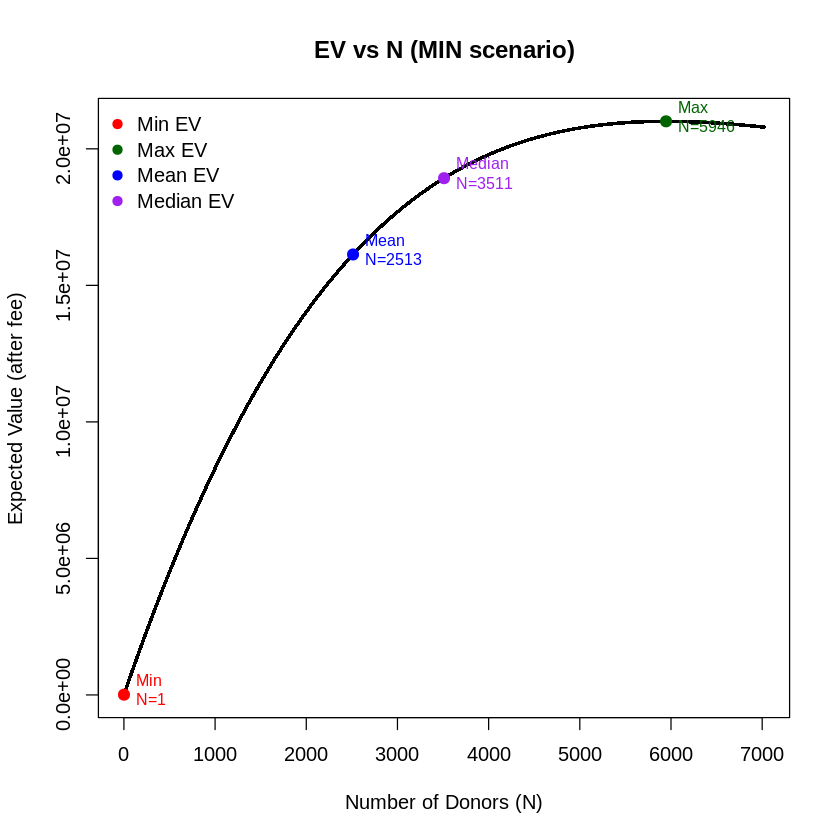

In [180]:
v <- v_list[[1]]   # misalnya v_min
ev_curve <- compute_ev_curve(
  model = model,
  bin_values = v,
  config = CONFIG,
  max_n = 7020
)

plot_ev_with_markers(
  ev_curve,
  title = "EV vs N (MIN scenario)"
)

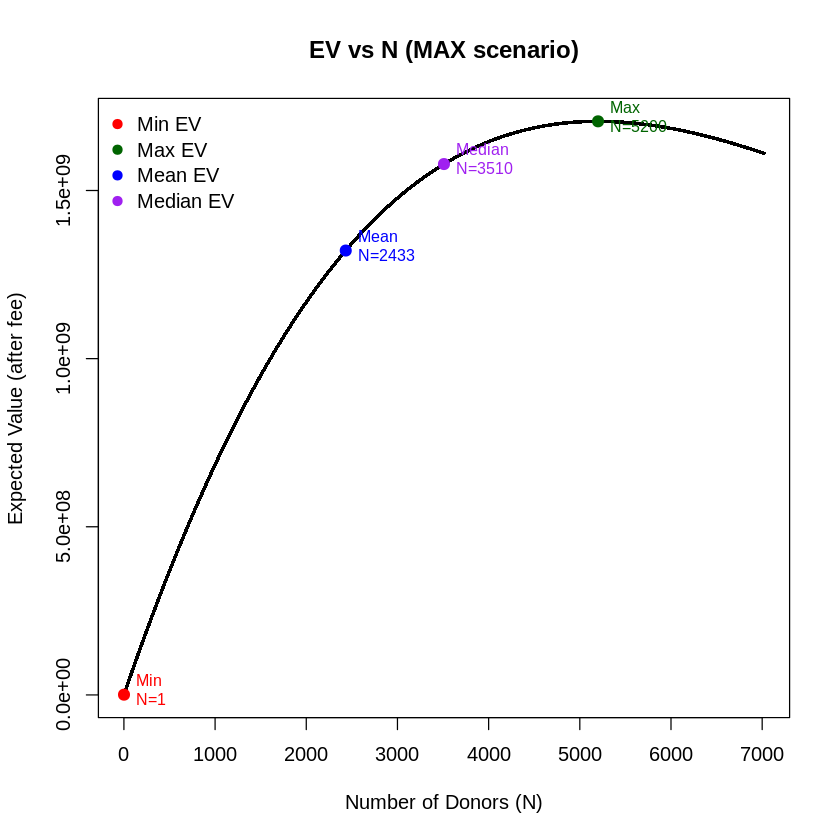

In [181]:
v <- v_list[[2]]
ev_curve <- compute_ev_curve(
  model = model,
  bin_values = v,
  config = CONFIG,
  max_n = 7020
)

plot_ev_with_markers(
  ev_curve,
  title = "EV vs N (MAX scenario)"
)

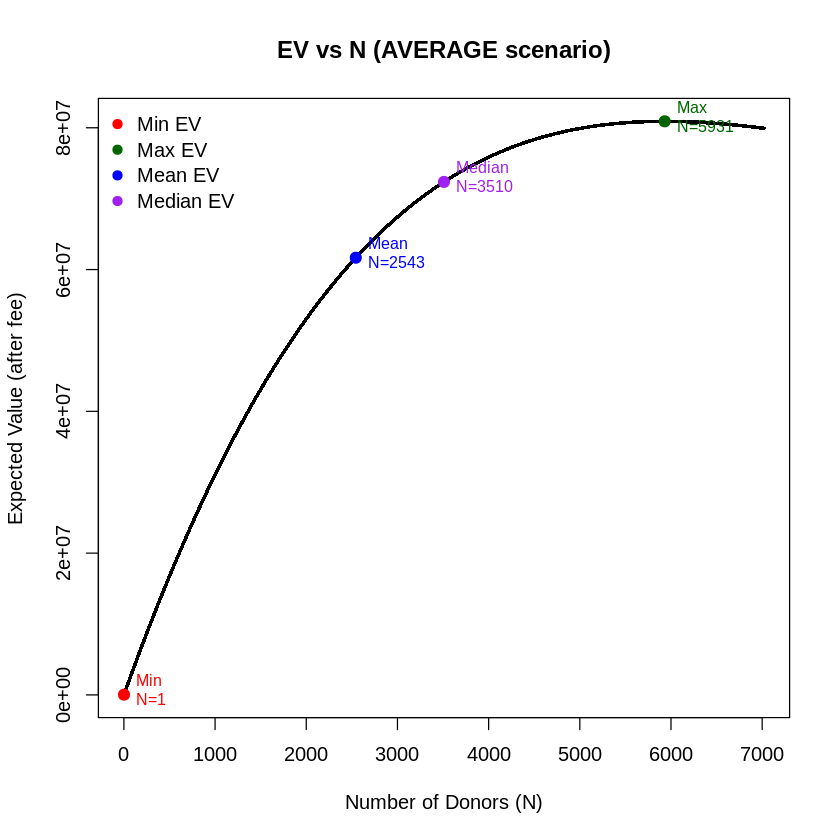

In [182]:
v <- v_list[[3]]
ev_curve <- compute_ev_curve(
  model = model,
  bin_values = v,
  config = CONFIG,
  max_n = 7020
)

plot_ev_with_markers(
  ev_curve,
  title = "EV vs N (AVERAGE scenario)"
)

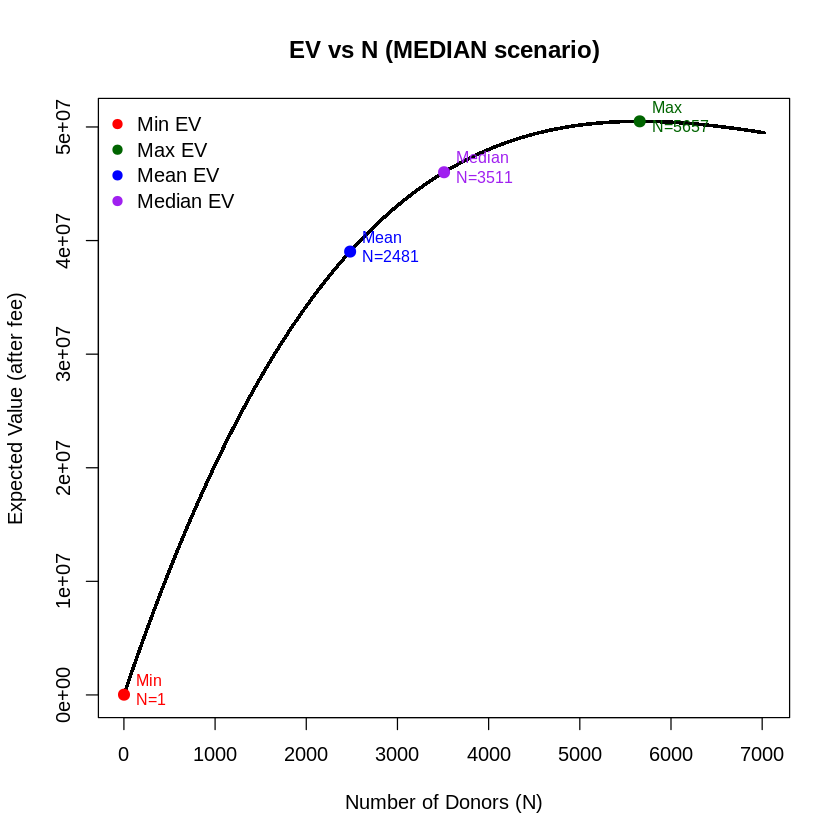

In [183]:
v <- v_list[[4]]
ev_curve <- compute_ev_curve(
  model = model,
  bin_values = v,
  config = CONFIG,
  max_n = 7020
)

plot_ev_with_markers(
  ev_curve,
  title = "EV vs N (MEDIAN scenario)"
)